In [2]:
import numpy as np
import pandas as pd

In [3]:
import torch
import torch.nn as nn
import timm

In [4]:
train='/kaggle/input/datasets/alhiya/dermnet-dataset/train'
test='/kaggle/input/datasets/alhiya/dermnet-dataset/test'

In [5]:

combined_path = '/kaggle/working/combined'
output_path = '/kaggle/working/final_dataset'

In [6]:
import shutil
import os

In [7]:
def combine_folders(train_path, test_path, combined_path):
    os.makedirs(combined_path, exist_ok=True)

    for dataset_path in [train_path, test_path]:
        for class_name in os.listdir(dataset_path):
            class_src = os.path.join(dataset_path, class_name)
            class_dst = os.path.join(combined_path, class_name)

            if not os.path.isdir(class_src):
                continue

            os.makedirs(class_dst, exist_ok=True)

            for img in os.listdir(class_src):
                src_file = os.path.join(class_src, img)

                # avoid overwrite if same filename exists
                dst_file = os.path.join(class_dst, img)
                if os.path.exists(dst_file):
                    base, ext = os.path.splitext(img)
                    dst_file = os.path.join(class_dst, base + "_copy" + ext)

                shutil.copy2(src_file, dst_file)

combine_folders(train, test, combined_path)

In [55]:
final_data='/kaggle/working/combined'

/tmp/ipykernel_55/4240974762.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()       # 🔥 Adjust layout so labels fit nicely


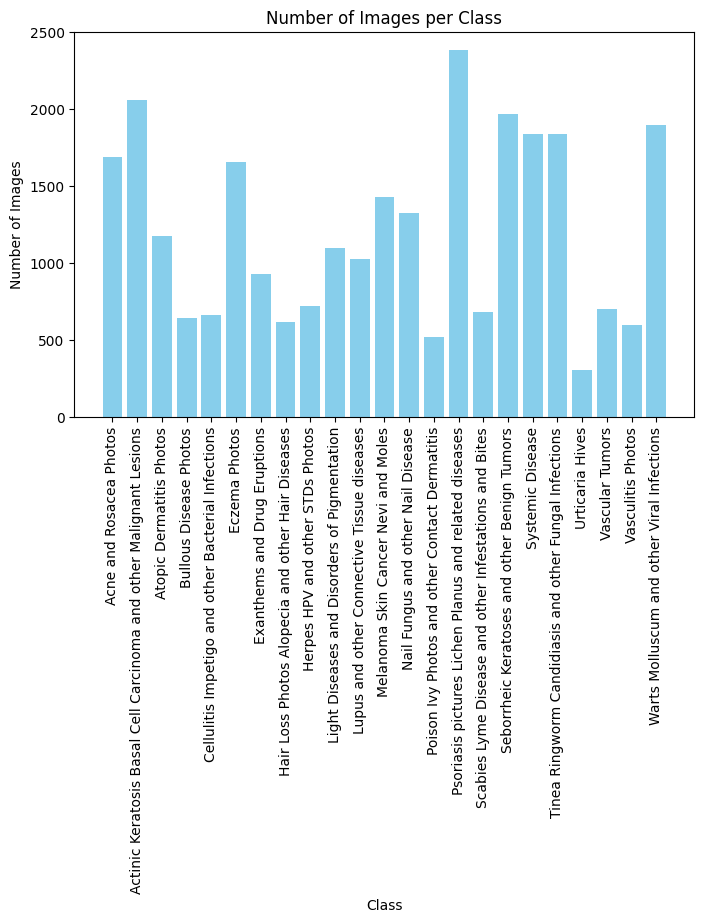

In [32]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# -------------------
# Dataset
# -------------------
transform = transforms.Compose([transforms.Resize((224,224))])
dataset = datasets.ImageFolder(final_data, transform=transform)  # make sure "train" is string path

# -------------------
# Count images per class
# -------------------
class_counts = {}
for label in dataset.targets:  # dataset.targets has class indices
    class_name = dataset.classes[label]
    if class_name in class_counts:
        class_counts[class_name] += 1
    else:
        class_counts[class_name] = 1

# -------------------
# Plot histogram / bar chart
# -------------------
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.xticks(rotation=90)  # 🔥 Rotate class names by 90 degrees
plt.tight_layout()       # 🔥 Adjust layout so labels fit nicely
plt.show()

In [33]:
class_counts

{'Acne and Rosacea Photos': 1686,
 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions': 2059,
 'Atopic Dermatitis Photos': 1177,
 'Bullous Disease Photos': 641,
 'Cellulitis Impetigo and other Bacterial Infections': 664,
 'Eczema Photos': 1655,
 'Exanthems and Drug Eruptions': 925,
 'Hair Loss Photos Alopecia and other Hair Diseases': 619,
 'Herpes HPV and other STDs Photos': 717,
 'Light Diseases and Disorders of Pigmentation': 1095,
 'Lupus and other Connective Tissue diseases': 1023,
 'Melanoma Skin Cancer Nevi and Moles': 1429,
 'Nail Fungus and other Nail Disease': 1323,
 'Poison Ivy Photos and other Contact Dermatitis': 516,
 'Psoriasis pictures Lichen Planus and related diseases': 2381,
 'Scabies Lyme Disease and other Infestations and Bites': 679,
 'Seborrheic Keratoses and other Benign Tumors': 1966,
 'Systemic Disease': 1835,
 'Tinea Ringworm Candidiasis and other Fungal Infections': 1835,
 'Urticaria Hives': 306,
 'Vascular Tumors': 698,
 'Vasculitis Photos'

In [34]:
import numpy as np

values = np.array(list(class_counts.values()))

In [35]:
values

array([1686, 2059, 1177,  641,  664, 1655,  925,  619,  717, 1095, 1023,
       1429, 1323,  516, 2381,  679, 1966, 1835, 1835,  306,  698,  597,
       1892])

In [36]:

low_threshold = np.percentile(values, 33)
high_threshold = np.percentile(values, 66)

print("Lower threshold:", low_threshold)
print("Upper threshold:", high_threshold)

Lower threshold: 702.94
Upper threshold: 1546.5200000000002


In [37]:
minority = {}
medium = {}
majority = {}

for cls_name, count in class_counts.items():
    if count < low_threshold:
        minority[cls_name] = count
    elif low_threshold <= count < high_threshold:
        medium[cls_name] = count
    else:
        majority[cls_name] = count




In [38]:
minority

{'Bullous Disease Photos': 641,
 'Cellulitis Impetigo and other Bacterial Infections': 664,
 'Hair Loss Photos Alopecia and other Hair Diseases': 619,
 'Poison Ivy Photos and other Contact Dermatitis': 516,
 'Scabies Lyme Disease and other Infestations and Bites': 679,
 'Urticaria Hives': 306,
 'Vascular Tumors': 698,
 'Vasculitis Photos': 597}

In [39]:
medium

{'Atopic Dermatitis Photos': 1177,
 'Exanthems and Drug Eruptions': 925,
 'Herpes HPV and other STDs Photos': 717,
 'Light Diseases and Disorders of Pigmentation': 1095,
 'Lupus and other Connective Tissue diseases': 1023,
 'Melanoma Skin Cancer Nevi and Moles': 1429,
 'Nail Fungus and other Nail Disease': 1323}

In [40]:
majority

{'Acne and Rosacea Photos': 1686,
 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions': 2059,
 'Eczema Photos': 1655,
 'Psoriasis pictures Lichen Planus and related diseases': 2381,
 'Seborrheic Keratoses and other Benign Tumors': 1966,
 'Systemic Disease': 1835,
 'Tinea Ringworm Candidiasis and other Fungal Infections': 1835,
 'Warts Molluscum and other Viral Infections': 1892}

In [41]:
import random
from torchvision import datasets, transforms


In [42]:
light_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.05, 0.01, 0.1, 0.02),
    transforms.ToTensor(),
       transforms.Normalize(
        [0.5545, 0.4224, 0.3888],
        [0.1843, 0.1582, 0.1532])
])

In [43]:
moderate_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.05, 0.02, 0.2, 0.1),
    transforms.ToTensor(),
       transforms.Normalize(
        [0.5545, 0.4224, 0.3888],
        [0.1843, 0.1582, 0.1532])
])

In [44]:
strong_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.2, 0.1, 0.2, 0.1),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1)),
    transforms.ToTensor(),
       transforms.Normalize(
        [0.5545, 0.4224, 0.3888],
        [0.1843, 0.1582, 0.1532])
])

In [68]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5545, 0.4224, 0.3888],[0.1843, 0.1582, 0.1532])
])


In [45]:
full_dataset = datasets.ImageFolder(root=final_data)

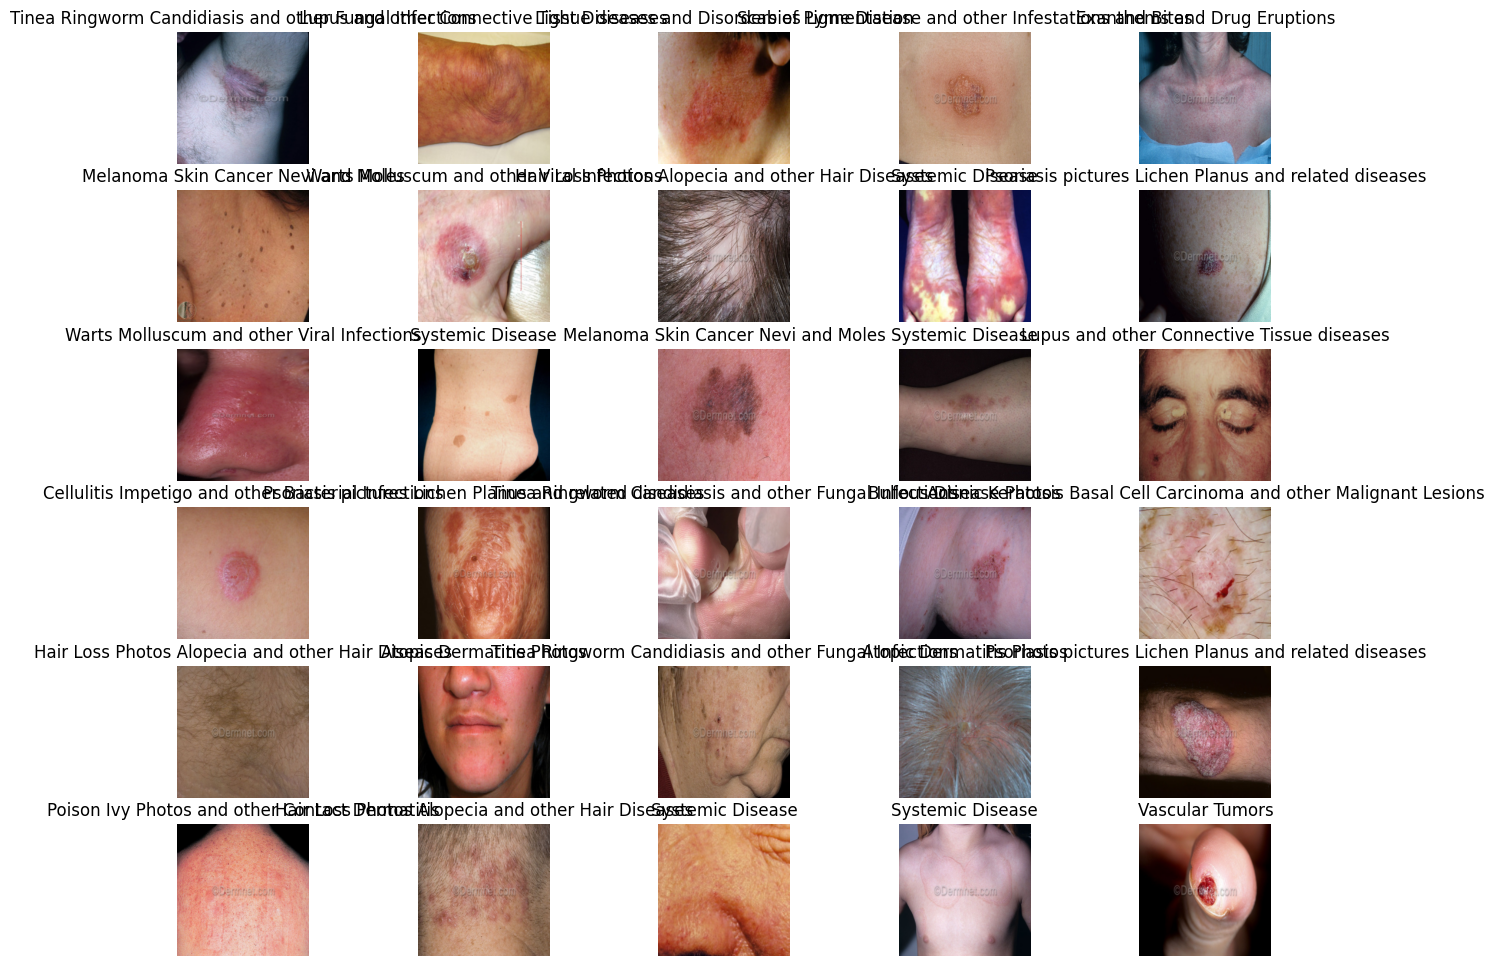

In [48]:
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root=final_data, transform=train_transform)

class_names = train_data.classes
num_images = 30
random_indices = random.sample(range(len(train_data)), num_images)

plt.figure(figsize=(15, 12))

for i, idx in enumerate(random_indices):
    image, label = train_data[idx]

    img = image.permute(1, 2, 0)  # C,H,W → H,W,C

    plt.subplot(6, 5, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.show()

In [ ]:
\

In [49]:
len(full_dataset)

27718

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [52]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [56]:
import numpy as np

full_dataset = datasets.ImageFolder(root=final_data)

indices = np.arange(len(full_dataset))
np.random.seed(42)
np.random.shuffle(indices)

In [57]:
total_size = len(indices)

train_end = int(train_ratio * total_size)
val_end = int((train_ratio + val_ratio) * total_size)

train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices=indices[val_end:]


In [99]:
len(train_indices)

19402

In [58]:
total_size

27718

In [59]:
class_level = {}

for cls in minority:
    class_level[cls] = "minority"
for cls in medium:
    class_level[cls] = "medium"
for cls in majority:
    class_level[cls] = "majority"

In [63]:
class_idx_to_level = {
    idx: class_level[class_name]
    for class_name, idx in full_dataset.class_to_idx.items()
}

In [64]:
from torch.utils.data import Dataset

class AugDataset(Dataset):
    def __init__(self, base_dataset, indices, class_idx_to_level,
                 light_aug, moderate_aug, strong_aug):
        self.base = base_dataset
        self.indices = indices
        self.class_idx_to_level = class_idx_to_level
        self.light_aug = light_aug
        self.moderate_aug = moderate_aug
        self.strong_aug = strong_aug

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]

        level = self.class_idx_to_level[label]

        if level == "minority":
            img = self.strong_aug(img)
        elif level == "medium":
            img = self.moderate_aug(img)
        else:
            img = self.light_aug(img)

        return img, label

In [65]:
train_dataset = AugDataset(
    full_dataset,
    train_indices,
    class_idx_to_level,
    light_aug,
    moderate_aug,
    strong_aug
)

In [66]:
class SimpleSubset(Dataset):
    def __init__(self, base, indices, transform=None):
        self.base = base
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]

        if self.transform:
            img = self.transform(img)

        return img, label

In [69]:
val_dataset = SimpleSubset(full_dataset, val_indices, val_transform)
test_dataset = SimpleSubset(full_dataset, test_indices, val_transform)

In [ ]:
# from torch.utils.data import Subset

# train_dataset = datasets.ImageFolder(
#     root=combined_path,
#     transform=train_transform
# )

# val_dataset = datasets.ImageFolder(
#     root=combined_path,
#     transform=val_transform
# )

# test_dataset = datasets.ImageFolder(
#     root=combined_path,
#     transform=val_transform  # same as val (NO augmentation)
# )

In [ ]:
# train_dataset = Subset(train_dataset, train_indices)
# val_dataset   = Subset(val_dataset, val_indices)
# test_dataset  = Subset(test_dataset, test_indices)

In [70]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [90]:
len(train_dataset)

19402

In [71]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
import torch.nn as nn
import timm

In [75]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=23,
    drop_rate=0.4# adjust if needed
).to(device)

In [73]:
from torch.utils.data import DataLoader, random_split,WeightedRandomSampler

In [76]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [78]:
import random
from torchvision import datasets, transforms

In [79]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,          # 🔥 KEY FIX
    weight_decay=0.1,

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [37]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# dataset = datasets.ImageFolder(train, transform=transform)
# loader = DataLoader(dataset, batch_size=32, shuffle=False)

# mean = 0.
# std = 0.
# total_images = 0

# for images, _ in loader:
#     batch_samples = images.size(0)
#     images = images.view(batch_samples, images.size(1), -1)
    
#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total_images += batch_samples

# mean /= total_images
# std /= total_images
# print(mean, std)

tensor([0.5545, 0.4224, 0.3888]) tensor([0.1843, 0.1582, 0.1532])


In [27]:
# from torchvision import transforms
# train_transform = transforms.Compose([
#     transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # keep most of image
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),  # reduce rotation
    
#     transforms.ColorJitter(
#         brightness=0.1,
#         contrast=0.1,
#         saturation=0.1,
#         hue=0.02
#     ),  # much safer
    
#     transforms.ToTensor(),
#     transforms.Normalize(
#         [0.5545, 0.4224, 0.3888],
#         [0.1843, 0.1582, 0.1532]
#     )
# ])

In [28]:
# val_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5545, 0.4224, 0.3888],[0.1843, 0.1582, 0.1532])
# ])


In [80]:
len(train_dataset)

19402

In [81]:
len(val_dataset)

4158

In [82]:
len(test_dataset)

4158

In [94]:
dataset = datasets.ImageFolder(final_data)


In [98]:
len(dataset)

27718

In [106]:
from collections import Counter

def get_class_counts(indices, dataset):
    labels = []

    for i in indices:   # ✅ use indices, not full dataset
        _, label = dataset[i]
        labels.append(label)

    return Counter(labels)

In [107]:
train_counts = get_counts(train_indices, dataset)
val_counts   = get_counts(val_indices, dataset)
test_counts  = get_counts(test_indices, dataset)

In [108]:
len(train_counts)

23

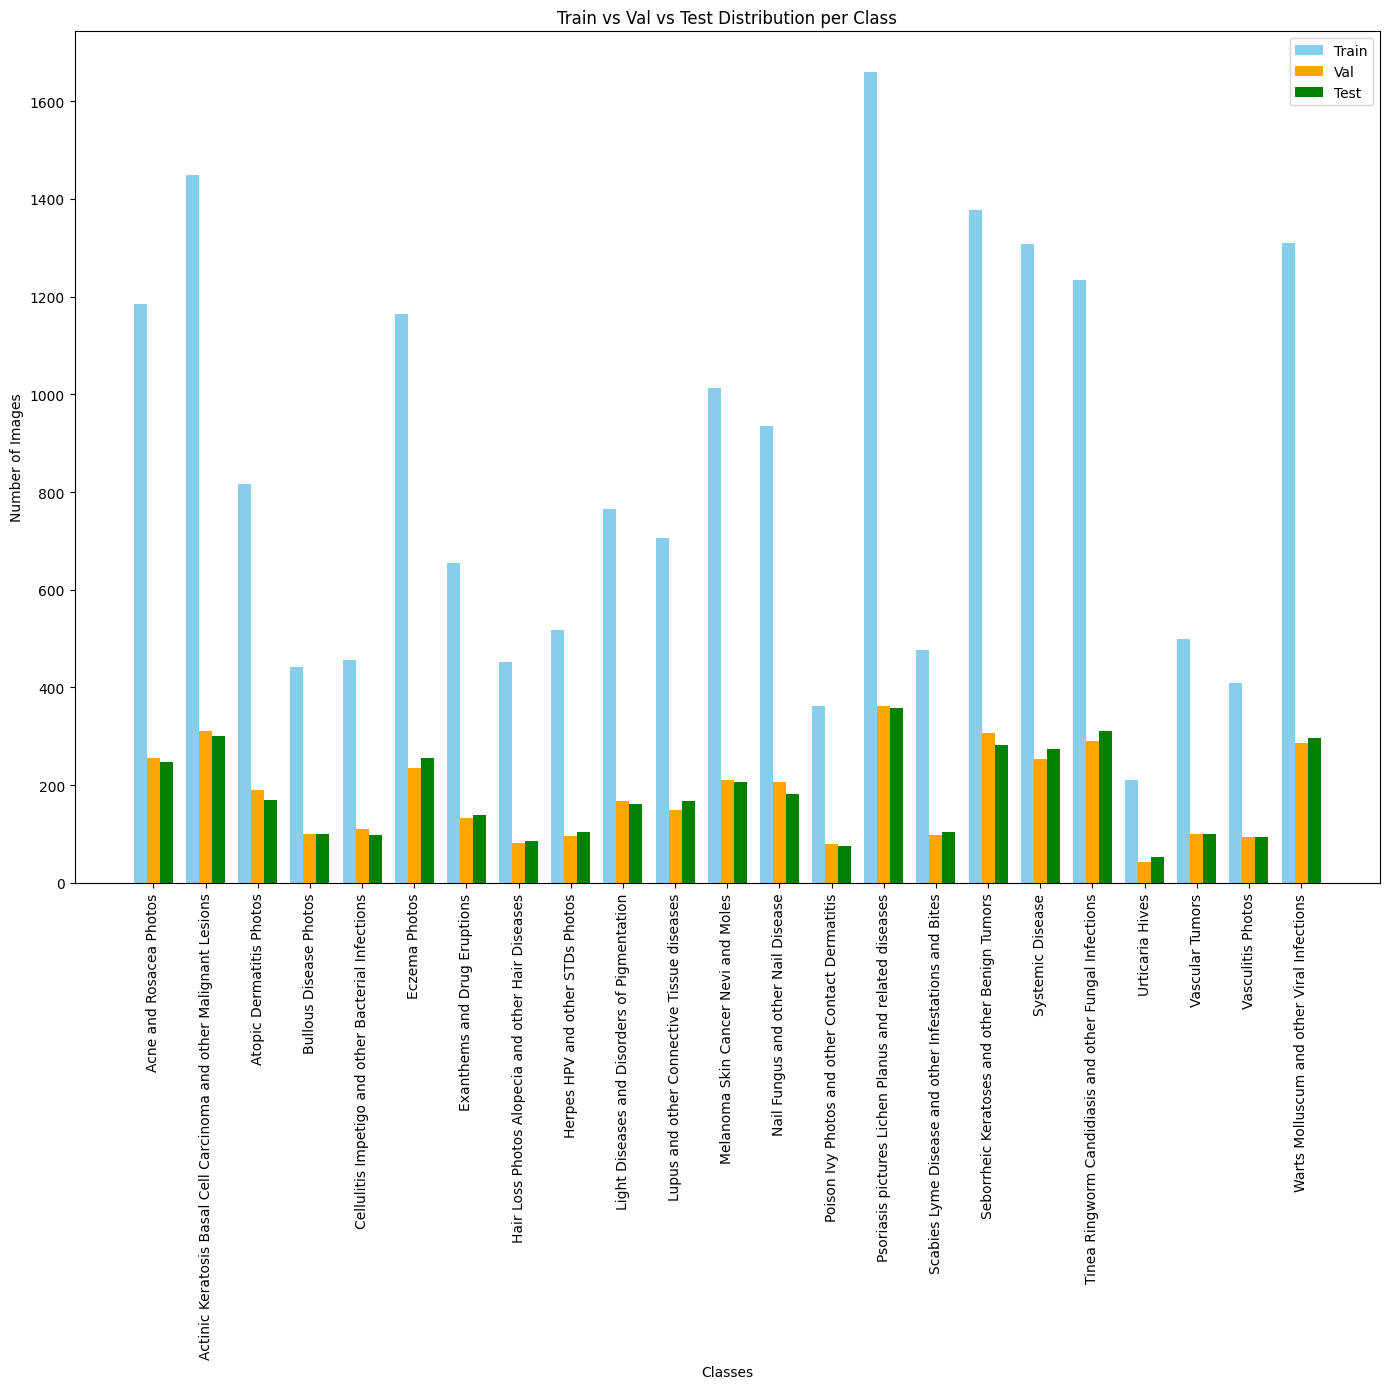

In [110]:
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(14,14))

plt.bar(x - width, train_counts, width, label="Train", color="skyblue")
plt.bar(x,         val_counts,   width, label="Val",   color="orange")
plt.bar(x + width, test_counts,  width, label="Test",  color="green")

plt.xticks(x, classes, rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Train vs Val vs Test Distribution per Class")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# def mixup_data(x, y, alpha=0.2):
#     lam = torch.distributions.Beta(alpha, alpha).sample().item()
#     batch_size = x.size(0)

#     index = torch.randperm(batch_size).to(x.device)

#     mixed_x = lam * x + (1 - lam) * x[index]
#     y_a, y_b = y, y[index]

#     return mixed_x, y_a, y_b, lam

In [120]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}

        # Initialize shadow weights
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                new_avg = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self):
        self.backup = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]
        self.backup = {}

In [138]:
def train_one_epoch(model, loader, ema):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # ema.update()  # ✅ IMPORTANT

        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [139]:
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [123]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [124]:
EPOCHS = 20
best_acc = 0

model.to(device)
ema = EMA(model)

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    train_loss, train_acc = train_one_epoch(model, train_loader, ema)  
    # 👆 pass ema inside so it updates per step

    # ---- VALIDATE with EMA ----
    ema.apply_shadow()
    val_loss, val_acc = validate(model, val_loader)
    ema.restore()

    # ---- LOG ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ---- SCHEDULER ----
    scheduler.step()   # or scheduler.step(val_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # ---- SAVE BEST (EMA weights) ----
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(ema.shadow, "best_swin_ema.pth")  # ✅ FIXED
        print("✅ Saved best EMA model")


Epoch 1
Train Loss: 2.4753, Acc: 0.2997
Val Loss: 2.7101, Acc: 0.2552
✅ Saved best EMA model

Epoch 2
Train Loss: 2.3521, Acc: 0.3414
Val Loss: 2.6761, Acc: 0.2706
✅ Saved best EMA model

Epoch 3
Train Loss: 2.2990, Acc: 0.3592
Val Loss: 2.6594, Acc: 0.2845
✅ Saved best EMA model

Epoch 4
Train Loss: 2.2686, Acc: 0.3697
Val Loss: 2.6499, Acc: 0.2917
✅ Saved best EMA model

Epoch 5
Train Loss: 2.2499, Acc: 0.3790
Val Loss: 2.6467, Acc: 0.2987
✅ Saved best EMA model

Epoch 6
Train Loss: 2.2290, Acc: 0.3895
Val Loss: 2.6476, Acc: 0.2992
✅ Saved best EMA model

Epoch 7
Train Loss: 2.2275, Acc: 0.3872
Val Loss: 2.6480, Acc: 0.3021
✅ Saved best EMA model

Epoch 8
Train Loss: 2.2151, Acc: 0.3878
Val Loss: 2.6500, Acc: 0.3042
✅ Saved best EMA model

Epoch 9
Train Loss: 2.2124, Acc: 0.3920
Val Loss: 2.6496, Acc: 0.3059
✅ Saved best EMA model

Epoch 10
Train Loss: 2.2090, Acc: 0.3899
Val Loss: 2.6487, Acc: 0.3083
✅ Saved best EMA model

Epoch 11
Train Loss: 2.2008, Acc: 0.3919
Val Loss: 2.6481,

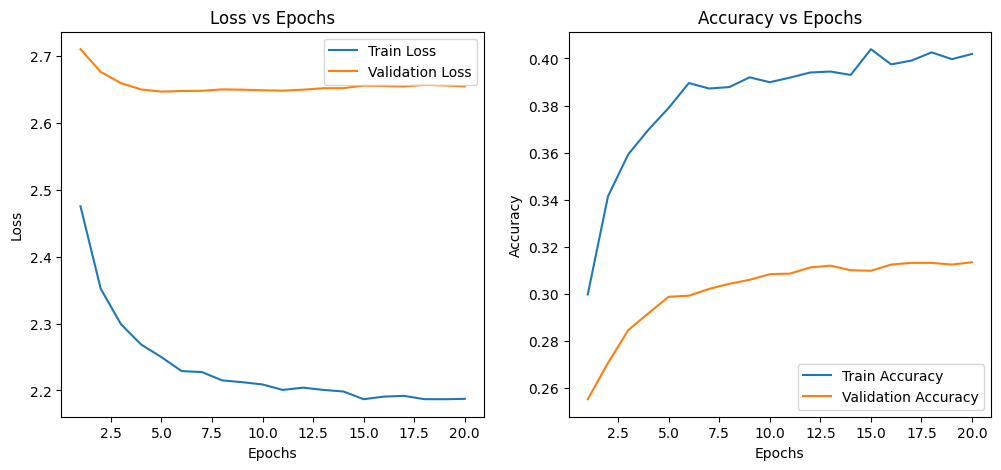

In [126]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [127]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [128]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.3127


In [129]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [130]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix

Classification Report:

                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.35      0.73      0.48       247
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.37      0.51      0.43       300
                                          Atopic Dermatitis Photos       0.41      0.05      0.09       170
                                            Bullous Disease Photos       0.33      0.01      0.02        99
                Cellulitis Impetigo and other Bacterial Infections       0.00      0.00      0.00        97
                                                     Eczema Photos       0.30      0.49      0.37       255
                                      Exanthems and Drug Eruptions       0.08      0.02      0.03       138
                 Hair Loss Photos Alopecia and other Hair Diseases       0.42      0.06      0.10        86
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


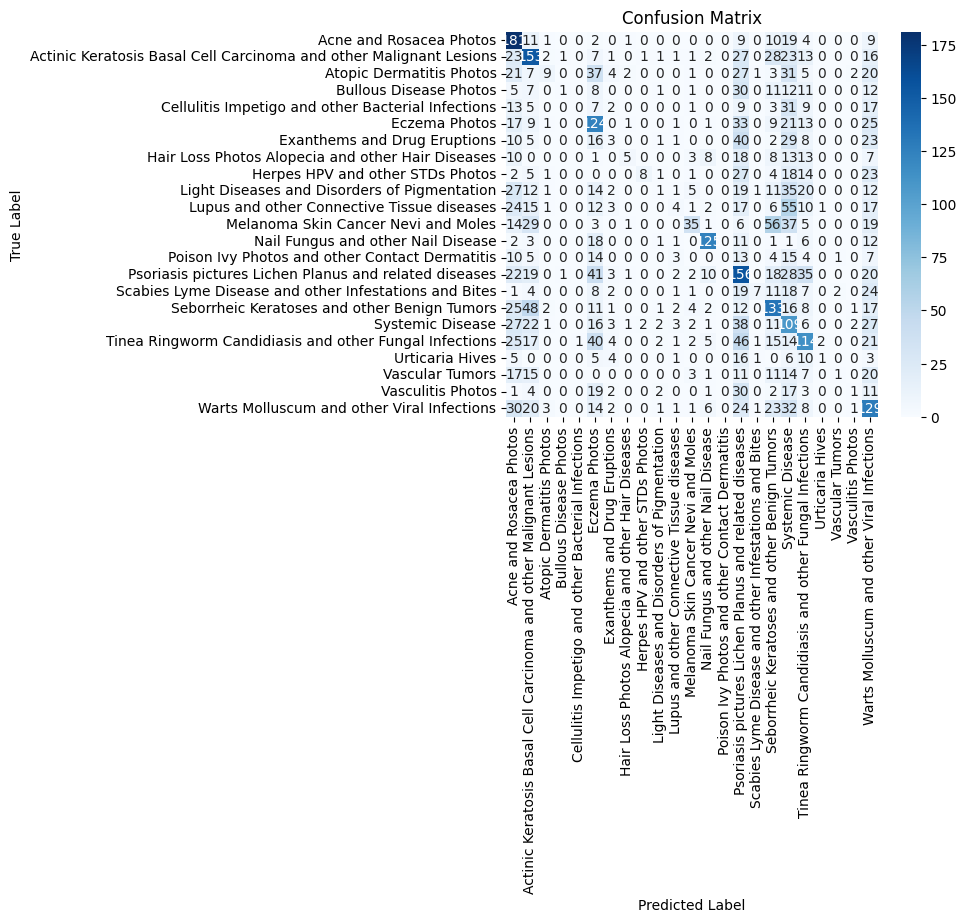

In [131]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [125]:
#convnext

In [133]:
cmodel = timm.create_model(
    "convnext_base",
    pretrained=True,
    num_classes=23 ,
    drop_rate=0.3# change to your dataset
).to(device)

In [134]:
for param in cmodel.parameters():
    param.requires_grad = False

for param in cmodel.head.parameters():
    param.requires_grad = True

In [135]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [140]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [141]:
EPOCHS = 20
best_acc = 0

model.to(device)
# ema = EMA(model)

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    train_loss, train_acc = train_one_epoch(cmodel, train_loader, ema)  
    # 👆 pass ema inside so it updates per step

    # ---- VALIDATE with EMA ----
    #ema.apply_shadow()
    val_loss, val_acc = validate(cmodel, val_loader)
    #ema.restore()

    # ---- LOG ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ---- SCHEDULER ----
    scheduler.step()   # or scheduler.step(val_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # ---- SAVE BEST (EMA weights) ----
    # if val_acc > best_acc:
    #     best_acc = val_acc
    #     torch.save(ema.shadow, "best_convnext.pth")  # ✅ FIXED
    #     print("✅ Saved best EMA model")


Epoch 1
Train Loss: 3.3766, Acc: 0.0450
Val Loss: 3.2897, Acc: 0.0426

Epoch 2
Train Loss: 3.3760, Acc: 0.0441
Val Loss: 3.2897, Acc: 0.0426

Epoch 3
Train Loss: 3.3723, Acc: 0.0461
Val Loss: 3.2897, Acc: 0.0426


KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = Test(
    cmodel, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()